In [ ]:
import numpy as np
import glob
import os
import pandas as pd 
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

In [2]:
img_dir=r"C:\Users\NJC\Desktop\New folder (2)\2026_geoai_arctic_challenge_v1.0\competition_release\train\images"
img_path=glob.glob(os.path.join(img_dir,"*.npz"))
img_path = sorted(img_path)
print(len(img_path))

756


In [3]:
annotation_path = r"C:\Users\NJC\Desktop\New folder (2)\2026_geoai_arctic_challenge_v1.0\competition_release\train\annotations\instances_train.json"
coco = COCO(annotation_path)
print(len(coco.getImgIds()))

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
756


In [4]:
data = np.load(img_path[0])
arr = data["image"]
H, W, C = arr.shape
print("Image shape:", arr.shape)
print("Height:", H)
print("Width:", W)
print("Channels:", C)

Image shape: (159, 289, 8)
Height: 159
Width: 289
Channels: 8


In [5]:
filename_to_img_info = {img["file_name"]: img for img in coco.loadImgs(coco.getImgIds())}
filename = os.path.basename(img_path[0])
coco_filename = f"images/{filename}"
img_info = filename_to_img_info[coco_filename]
coco_image_id = img_info["id"]
ann_ids = coco.getAnnIds(imgIds=coco_image_id)
anns = coco.loadAnns(ann_ids)
print(f"NPZ filename: {filename}")
print(f"COCO image ID: {coco_image_id}")
print(f"Number of annotations: {len(anns)}")

NPZ filename: train_000001.npz
COCO image ID: 1
Number of annotations: 1


In [6]:
H, W = arr.shape[0], arr.shape[1]
mask = np.zeros((H, W), dtype=np.int8)
for ann in anns:
    binary_mask = coco.annToMask(ann)
    mask[binary_mask == 1] = 1
print("Mask shape:", mask.shape)
print("RTS pixels:", mask.sum())


Mask shape: (159, 289)
RTS pixels: 21105


In [7]:

assert arr.shape[:2] == mask.shape, "Height and width of image and mask do not match!"
assert C == 8, f"Expected 8 channels, but found {C}!"
print("all good")

all good


In [8]:
pad_width = ((0, 2), (0, 2), (0, 0))
padded_arr = np.pad(arr, pad_width=pad_width, mode="constant", constant_values=0)
print("Original shape:", arr.shape)
print("Padded shape:", padded_arr.shape)

Original shape: (159, 289, 8)
Padded shape: (161, 291, 8)


In [9]:
row=0
col=0
patch = padded_arr[row : row + 3, col : col + 3, :]
print("Patch shape:", patch.shape)
print(patch[:, :, 0]) #red 
feature_sum = patch.sum(axis=(0, 1))
print("Feature sums shape:", feature_sum.shape)
print("Feature sums of red :",feature_sum[0])
print("Feature sums of all channels :",feature_sum)

Patch shape: (3, 3, 8)
[[190. 190. 181.]
 [186. 174. 174.]
 [174. 159. 160.]]
Feature sums shape: (8,)
Feature sums of red : 1588.0
Feature sums of all channels : [ 1.5880000e+03  1.4980000e+03  1.2740000e+03  9.4182044e-01
  4.9895020e+00  1.3804115e+03  1.1958000e+04 -2.0536847e+00]


In [10]:
mask_pad_width = ((0, 2), (0, 2))
padded_mask = np.pad(mask, pad_width=mask_pad_width, mode="constant", constant_values=0)
target_patch = padded_mask[row : row + 3, col : col + 3]
rts_count = target_patch.sum()
target = 1 if rts_count >= 5 else 0
print("Target patch shape:", target_patch.shape)
print("Target patch:\n", target_patch)
print("RTS count", rts_count)
print("final target label:", target)

Target patch shape: (3, 3)
Target patch:
 [[0 0 0]
 [0 0 0]
 [0 0 0]]
RTS count 0
final target label: 0


In [11]:
data_row = np.append(feature_sum, target)
print("Row shape:", data_row.shape)
print("Combined Row:\n", data_row)

Row shape: (9,)
Combined Row:
 [ 1.58800000e+03  1.49800000e+03  1.27400000e+03  9.41820443e-01
  4.98950195e+00  1.38041150e+03  1.19580000e+04 -2.05368471e+00
  0.00000000e+00]


handling nan,

In [ ]:
nan_mask = np.isnan(arr)
print("Total NaNs:", nan_mask.sum())
print("NaNs per channel:", nan_mask.sum(axis=(0, 1)))
pixels_with_nan = nan_mask.any(axis=-1).sum()
print("Pixels with at least one NaN:", pixels_with_nan)
padded_nan_mask = np.pad(nan_mask, pad_width=((0, 2), (0, 2), (0, 0)), constant_values=False)

H, W = arr.shape[:2]
nan_counts_3x3 = np.zeros((H, W, 8), dtype=int)

for r_offset in range(3):
    for c_offset in range(3):
        nan_counts_3x3 += padded_nan_mask[r_offset : r_offset + H, c_offset : c_offset + W, :]
patches_all_nan = (nan_counts_3x3 == 9).sum(axis=(0, 1))
print("3x3 patches where all 9 values are NaN (by channel):", patches_all_nan)

Total NaNs: 199
NaNs per channel: [53 53 93  0  0  0  0  0]
Pixels with at least one NaN: 93
3x3 patches where all 9 values are NaN (by channel): [0 0 0 0 0 0 0 0]


In [ ]:
import numpy as np
C = 8 
total_nan = 0
nan_per_channel = np.zeros(C, dtype=np.int64)
pixels_with_nan = 0
all_nan_3x3_per_channel = np.zeros(C, dtype=np.int64)

for i, path in enumerate(img_path):
    data = np.load(path)
    image = data["image"]
    H, W, _ = image.shape
    nan_mask = np.isnan(image)
    total_nan += nan_mask.sum()
    nan_per_channel += nan_mask.sum(axis=(0, 1))
    pixels_with_nan += nan_mask.any(axis=-1).sum()
    
    padded_nan = np.pad(nan_mask, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=False)
    nan_counts_3x3 = np.zeros((H, W, C), dtype=np.int8)
    
    for r_offset in range(3):
        for c_offset in range(3):
            nan_counts_3x3 += padded_nan[r_offset:r_offset + H, c_offset:c_offset + W, :]
            
    all_nan_3x3_per_channel += (nan_counts_3x3 == 9).sum(axis=(0, 1))
    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(img_path)} images")
print("Total NaNs:", total_nan)
print("NaNs per channel:", nan_per_channel)
print("Pixels with at least one NaN:", pixels_with_nan)
print("3x3 patches with all 9 values NaN by channel:", all_nan_3x3_per_channel)

Processed 100/756 images
Processed 200/756 images
Processed 300/756 images
Processed 400/756 images
Processed 500/756 images
Processed 600/756 images
Processed 700/756 images
Total NaNs: 446116
NaNs per channel: [  1214   1324   2576    300 216806 223596      0    300]
Pixels with at least one NaN: 226479
3x3 patches with all 9 values NaN by channel: [     4      4      4     69 204531 211039      0     69]


Image with most Channel 5 NaNs: Index 419
Path: C:\Users\NJC\Desktop\New folder (2)\2026_geoai_arctic_challenge_v1.0\competition_release\train\images\train_000420.npz
NaN count in Channel 5 for this image: 25012


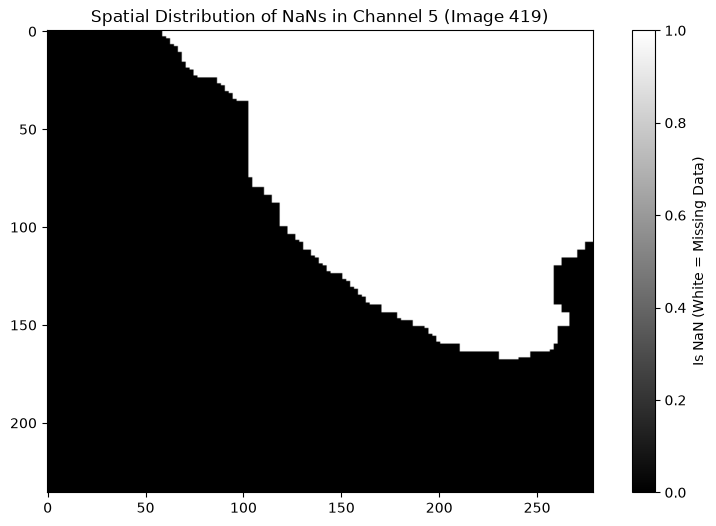

In [19]:
max_nan_count = 0
worst_image_idx = -1
worst_image_path = ""

for i, path in enumerate(img_path):
    data = np.load(path)
    image = data["image"]
    ch5_nans = np.isnan(image[:, :, 4]).sum()
    
    if ch5_nans > max_nan_count:
        max_nan_count = ch5_nans
        worst_image_idx = i
        worst_image_path = path

print(f"Image with most Channel 5 NaNs: Index {worst_image_idx}")
print(f"Path: {worst_image_path}")
print(f"NaN count in Channel 5 for this image: {max_nan_count}")

worst_data = np.load(worst_image_path)
worst_image = worst_data["image"]
ch5_nan_mask = np.isnan(worst_image[:, :, 4])

plt.figure(figsize=(10, 6))
plt.title(f"Spatial Distribution of NaNs in Channel 5 (Image {worst_image_idx})")
plt.imshow(ch5_nan_mask, cmap="gray")
plt.colorbar(label="Is NaN (White = Missing Data)")
plt.show()

In [ ]:
nan_mask = np.isnan(image)
safe_image = np.nan_to_num(image, nan=0.0)
real_pixels = np.ones_like(image, dtype=np.float32)

padded_img = np.pad(safe_image, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=0.0)
padded_nan = np.pad(nan_mask, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=False)
padded_real = np.pad(real_pixels, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=0.0)

H, W, C = image.shape
spatial_sums = np.zeros((H, W, C), dtype=np.float32)
nan_counts = np.zeros((H, W, C), dtype=np.int8)
real_pixel_counts = np.zeros((H, W, C), dtype=np.int8)

for r_offset in range(3):
    for c_offset in range(3):
        spatial_sums += padded_img[r_offset:r_offset + H, c_offset:c_offset + W, :]
        nan_counts += padded_nan[r_offset:r_offset + H, c_offset:c_offset + W, :]
        real_pixel_counts += padded_real[r_offset:r_offset + H, c_offset:c_offset + W, :].astype(np.int8)
        
all_nan_condition = (nan_counts == real_pixel_counts) & (real_pixel_counts > 0)
spatial_sums[all_nan_condition] = np.nan

In [ ]:
def get_binary_mask(img_path):
    filename = os.path.basename(img_path)
    coco_filename = f"images/{filename}"

    img_info = filename_to_img_info[coco_filename]
    coco_image_id = img_info["id"]

    ann_ids = coco.getAnnIds(imgIds=coco_image_id)
    anns = coco.loadAnns(ann_ids)
    
    data = np.load(img_path)
    image = data["image"]
    H, W, _ = image.shape

    mask = np.zeros((H, W), dtype=np.int8)
    for ann in anns:
        binary_mask = coco.annToMask(ann)
        mask[binary_mask == 1] = 1

    return mask


def process_single_image(img_path, coco_mask):
    data = np.load(img_path)
    image = data["image"]

    H, W, C = image.shape

    assert C == 8
    assert coco_mask.shape == (H, W)
    nan_mask = np.isnan(image)
    safe_image = np.where(nan_mask, 0.0, image)

    real_pixels = np.ones_like(image, dtype=np.float32)

    padded_img = np.pad(safe_image, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=0.0)
    padded_nan = np.pad(nan_mask, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=False)
    padded_real = np.pad(real_pixels, ((0, 2), (0, 2), (0, 0)), mode="constant", constant_values=0.0)
    spatial_sums = np.zeros((H, W, C), dtype=np.float32)
    nan_counts = np.zeros((H, W, C), dtype=np.int8)
    real_pixel_counts = np.zeros((H, W, C), dtype=np.int8)

    for r in range(3):
        for c in range(3):
            spatial_sums += padded_img[r:r + H, c:c + W, :]
            nan_counts += padded_nan[r:r + H, c:c + W, :]
            real_pixel_counts += padded_real[r:r + H, c:c + W, :].astype(np.int8)
    all_nan = (nan_counts == real_pixel_counts) & (real_pixel_counts > 0)

    spatial_sums[all_nan] = np.nan
    padded_mask = np.pad(coco_mask.astype(np.float32), ((0, 2), (0, 2)), mode="constant", constant_values=0.0)

    target_count = np.zeros((H, W), dtype=np.float32)

    for r in range(3):
        for c in range(3):
            target_count += padded_mask[r:r + H, c:c + W]

    final_target = (target_count >= 5).astype(np.int8)
    features_flat = spatial_sums.reshape(-1, C)
    target_flat = final_target.reshape(-1, 1)

    return np.hstack([features_flat, target_flat])

# Test on the first image
test_path = img_path[0]

test_mask = get_binary_mask(test_path)
test_output = process_single_image(test_path, test_mask)

column_names = [f"channel_{i+1}" for i in range(8)] + ["target"]
test_df = pd.DataFrame(test_output, columns=column_names)

print("Image:", os.path.basename(test_path))
print("Output shape:", test_df.shape)
print("\nFirst 5 rows:")
print(test_df.head())
print("\nNaNs per feature:")
print(test_df.iloc[:, :8].isna().sum().to_numpy())
print("\nTarget counts:")
print(test_df["target"].value_counts())

Image: train_000001.npz
Output shape: (45951, 9)

First 5 rows:
   channel_1  channel_2  channel_3  channel_4  channel_5    channel_6  \
0     1588.0     1498.0     1274.0   0.941820   4.989502  1380.411499   
1     1540.0     1452.0     1227.0   0.732161   6.880127  1401.771240   
2     1519.0     1428.0     1204.0   0.692870   8.066406  1430.217407   
3     1526.0     1434.0     1210.0   0.653580   8.510010  1462.844360   
4     1537.0     1443.0     1218.0   0.644525   8.280029  1498.647583   

   channel_7  channel_8  target  
0    11958.0  -2.053685     0.0  
1    10869.0  -1.949091     0.0  
2    10028.5  -1.889170     0.0  
3     9271.5  -1.829249     0.0  
4     8735.5  -1.761911     0.0  

NaNs per feature:
[0 0 0 0 0 0 0 0]

Target counts:
target
0.0    25003
1.0    20948
Name: count, dtype: int64


In [36]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

output_file = "adaptive_patching_3x3.parquet"
column_names = [f"channel_{i+1}" for i in range(8)] + ["target"]

writer = None
total_rows = 0
processed_images = 0
failed_images = []

try:
    if os.path.exists(output_file):
        os.remove(output_file)
    for i, image_path in enumerate(img_path):
        try:
            mask = get_binary_mask(image_path)
            image_output = process_single_image(image_path, mask)
            df_chunk = pd.DataFrame(image_output, columns=column_names)
            table = pa.Table.from_pandas(df_chunk, preserve_index=False)
            if writer is None:
                writer = pq.ParquetWriter(output_file, table.schema, compression="snappy")
            writer.write_table(table)
            total_rows += len(df_chunk)
            processed_images += 1
            print(f"Processed {i+1}/{len(img_path)} | {os.path.basename(image_path)} | Rows: {len(df_chunk)} | Total: {total_rows}")
        except Exception as e:
            failed_images.append((os.path.basename(image_path), str(e)))
            print(f"FAILED {i+1}/{len(img_path)} | {os.path.basename(image_path)} | {e}")

finally:
    if writer is not None:
        writer.close()
print("Images processed:", processed_images)
print("Images failed:", len(failed_images))
print("Total rows written:", total_rows)
print("Output file:", output_file)

if failed_images:
    print("\nFailed images:")
    for filename, error in failed_images:
        print(filename, "->", error)

Processed 1/756 | train_000001.npz | Rows: 45951 | Total: 45951
Processed 2/756 | train_000002.npz | Rows: 45662 | Total: 91613
Processed 3/756 | train_000003.npz | Rows: 39867 | Total: 131480
Processed 4/756 | train_000004.npz | Rows: 39576 | Total: 171056
Processed 5/756 | train_000005.npz | Rows: 45662 | Total: 216718
Processed 6/756 | train_000006.npz | Rows: 39867 | Total: 256585
Processed 7/756 | train_000007.npz | Rows: 45662 | Total: 302247
Processed 8/756 | train_000008.npz | Rows: 39576 | Total: 341823
Processed 9/756 | train_000009.npz | Rows: 59000 | Total: 400823
Processed 10/756 | train_000010.npz | Rows: 40296 | Total: 441119
Processed 11/756 | train_000011.npz | Rows: 45373 | Total: 486492
Processed 12/756 | train_000012.npz | Rows: 39867 | Total: 526359
Processed 13/756 | train_000013.npz | Rows: 40158 | Total: 566517
Processed 14/756 | train_000014.npz | Rows: 58506 | Total: 625023
Processed 15/756 | train_000015.npz | Rows: 58800 | Total: 683823
Processed 16/756 | tr

In [38]:
import pyarrow.parquet as pq

pf = pq.ParquetFile("adaptive_patching_3x3.parquet")

print("Rows:", pf.metadata.num_rows)
print("Columns:", pf.metadata.num_columns)
print("Column names:", pf.schema.names)
print("Row groups:", pf.num_row_groups)


Rows: 38677917
Columns: 9
Column names: ['channel_1', 'channel_2', 'channel_3', 'channel_4', 'channel_5', 'channel_6', 'channel_7', 'channel_8', 'target']
Row groups: 756


In [40]:
df = pf.read_row_group(0).to_pandas()
print("Shape:", df.shape)
print(df.head())
print(df.sample(10, random_state=42))

Shape: (45951, 9)
   channel_1  channel_2  channel_3  channel_4  channel_5    channel_6  \
0     1588.0     1498.0     1274.0   0.941820   4.989502  1380.411499   
1     1540.0     1452.0     1227.0   0.732161   6.880127  1401.771240   
2     1519.0     1428.0     1204.0   0.692870   8.066406  1430.217407   
3     1526.0     1434.0     1210.0   0.653580   8.510010  1462.844360   
4     1537.0     1443.0     1218.0   0.644525   8.280029  1498.647583   

   channel_7  channel_8  target  
0    11958.0  -2.053685     0.0  
1    10869.0  -1.949091     0.0  
2    10028.5  -1.889170     0.0  
3     9271.5  -1.829249     0.0  
4     8735.5  -1.761911     0.0  
       channel_1  channel_2  channel_3  channel_4  channel_5    channel_6  \
20252     1442.0     1311.0     1134.0   1.534881  -1.217529  1506.256104   
44489     1480.0     1386.0     1192.0   0.771127  -1.347656  1562.042725   
38383     1455.0     1368.0     1142.0   0.581221  -2.637451  1622.636841   
41171     1110.0     1053.0    